# Análisis exploratorio de incidencia delictiva en México

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data/delitos.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/delitos.csv'

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

/var/folders/hm/f01qht_n4v7frppw014pwprc0000gn/T/ipykernel_75594/973093301.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['fecha'] = pd.to_datetime(df_filtrado['fecha'])


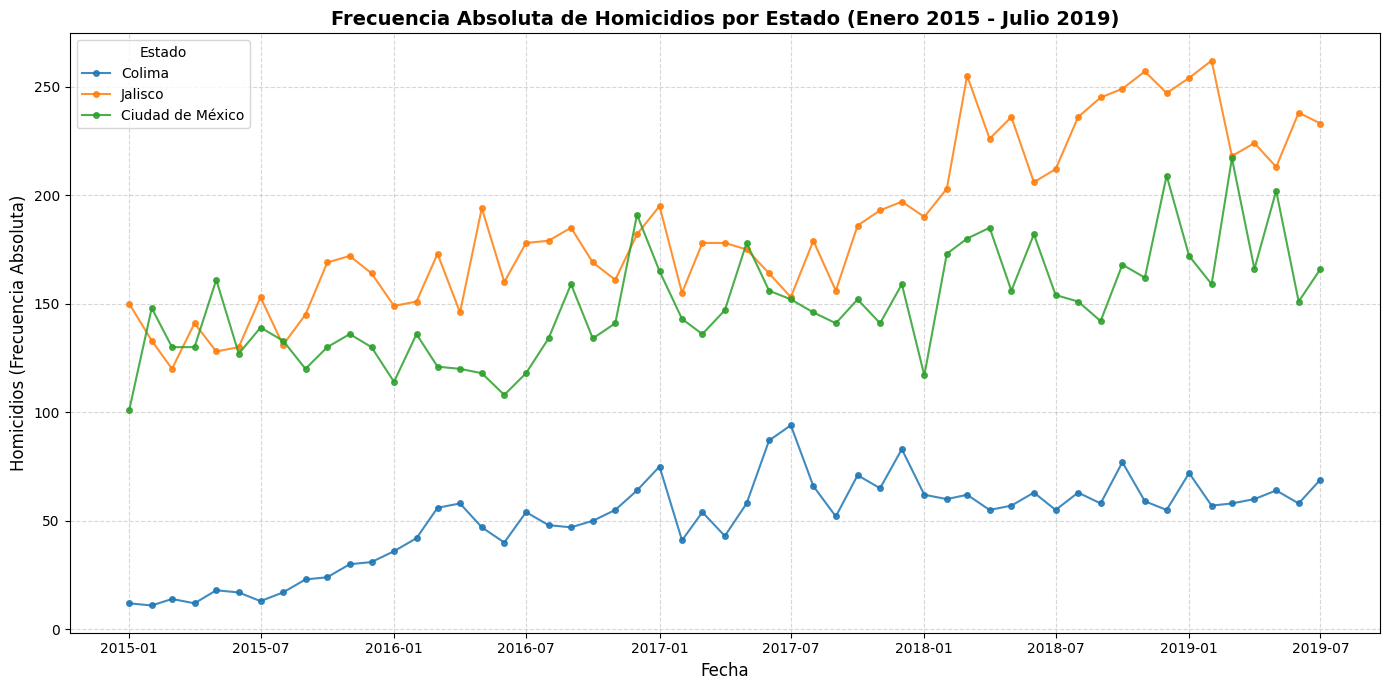

In [ ]:
# Ejercicio 1: Serie de tiempo de homicidios en 3 estados elegidos (2015-01 a 2019-07)
# Nota: Como el dataset delitos.csv agrupó los tipos de homicidio (doloso/culposo) bajo 'Homicidio',
# usaremos 'Homicidio' como tipo de delito.
df_homicidios = df[
    (df['tipo_de_delito'] == 'Homicidio') &
    (df['fecha'] >= '2015-01-01') &
    (df['fecha'] <= '2019-07-31')
]

# Seleccionamos 3 estados de la república
estados_elegidos = ['Colima', 'Jalisco', 'Ciudad de México']
df_filtrado = df_homicidios[df_homicidios['entidad'].isin(estados_elegidos)]

# Asegurar que la fecha esté en formato datetime para graficar
df_filtrado['fecha'] = pd.to_datetime(df_filtrado['fecha'])

# Graficar
plt.figure(figsize=(14, 7))
for estado in estados_elegidos:
    data_estado = df_filtrado[df_filtrado['entidad'] == estado].sort_values('fecha')
    plt.plot(data_estado['fecha'], data_estado['frecuencia'], label=estado, marker='o', markersize=4, alpha=0.85)

plt.title('Frecuencia Absoluta de Homicidios por Estado (Enero 2015 - Julio 2019)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Homicidios (Frecuencia Absoluta)', fontsize=12)
plt.legend(title='Estado')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [16]:
print("=== RESPUESTAS A LAS PREGUNTAS DEL EJERCICIO 2 ===\n")

# 1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
# Nota: Todos los homicidios (dolosos y culposos) están bajo 'Homicidio' en la columna 'tipo_de_delito'.
homicidios_colima_2018 = df[(df['entidad'] == 'Colima') & (df['anio'] == 2018) & (df['tipo_de_delito'] == 'Homicidio')]['frecuencia'].sum()
print(f"1. Homicidios en Colima durante 2018 (total unificado): {homicidios_colima_2018:.0f}")

# 2. ¿Cuántos robos de vehículo automotor ha habido en el 2019?
# Nota: Todos los robos están bajo 'Robo' en la columna 'tipo_de_delito'.
robos_2019 = df[(df['anio'] == 2019) & (df['tipo_de_delito'] == 'Robo')]['frecuencia'].sum()
print(f"2. Robos en la República Mexicana durante 2019 (total unificado): {robos_2019:.0f}")

# 3. Obten la suma de homicidos y feminicidios en toda la República Mexicana en cada año.
homicidios_feminicidios = df[df['tipo_de_delito'].isin(['Homicidio', 'Feminicidio'])]
suma_anual = homicidios_feminicidios.groupby('anio')['frecuencia'].sum().reset_index()
print("\n3. Suma anual de Homicidios y Feminicidios en todo el país:")
display(suma_anual)

# 4. ¿En qué mes y en qué entidad (el dataset no tiene municipios) ha ocurrido el mayor número de feminicidios?
df_feminicidios = df[df['tipo_de_delito'] == 'Feminicidio']
max_fem_registro = df_feminicidios.loc[df_feminicidios['frecuencia'].idxmax()]
print(f"\n4. Registro mensual con mayor número de feminicidios:")
print(f"   - Estado (Entidad): {max_fem_registro['entidad']}")
print(f"   - Mes: {max_fem_registro['nombre_mes']} de {max_fem_registro['anio']}")
print(f"   - Cantidad en el mes: {max_fem_registro['frecuencia']:.0f} feminicidios")

# 5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?
fem_anual_estado = df_feminicidios.groupby(['anio', 'entidad'])['frecuencia'].sum().reset_index()
max_fem_anual_estado = fem_anual_estado.loc[fem_anual_estado['frecuencia'].idxmax()]
print(f"\n5. Mayor número de feminicidios acumulados en un año completo por estado:")
print(f"   - Estado (Entidad): {max_fem_anual_estado['entidad']}")
print(f"   - Año: {max_fem_anual_estado['anio']}")
print(f"   - Cantidad acumulada: {max_fem_anual_estado['frecuencia']:.0f} feminicidios")


=== RESPUESTAS A LAS PREGUNTAS DEL EJERCICIO 2 ===

1. Homicidios en Colima durante 2018 (total unificado): 726
2. Robos en la República Mexicana durante 2019 (total unificado): 766096

3. Suma anual de Homicidios y Feminicidios en todo el país:


,anio,frecuencia
0,2015,31744.0
1,2016,36018.0
2,2017,42068.0
3,2018,45385.0
4,2019,45822.0
5,2020,44223.0
6,2021,44960.0
7,2022,43845.0
8,2023,42846.0
9,2024,22307.0



4. Registro mensual con mayor número de feminicidios:
   - Estado (Entidad): México
   - Mes: julio de 2020
   - Cantidad en el mes: 19 feminicidios

5. Mayor número de feminicidios acumulados en un año completo por estado:
   - Estado (Entidad): México
   - Año: 2020
   - Cantidad acumulada: 151 feminicidios


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

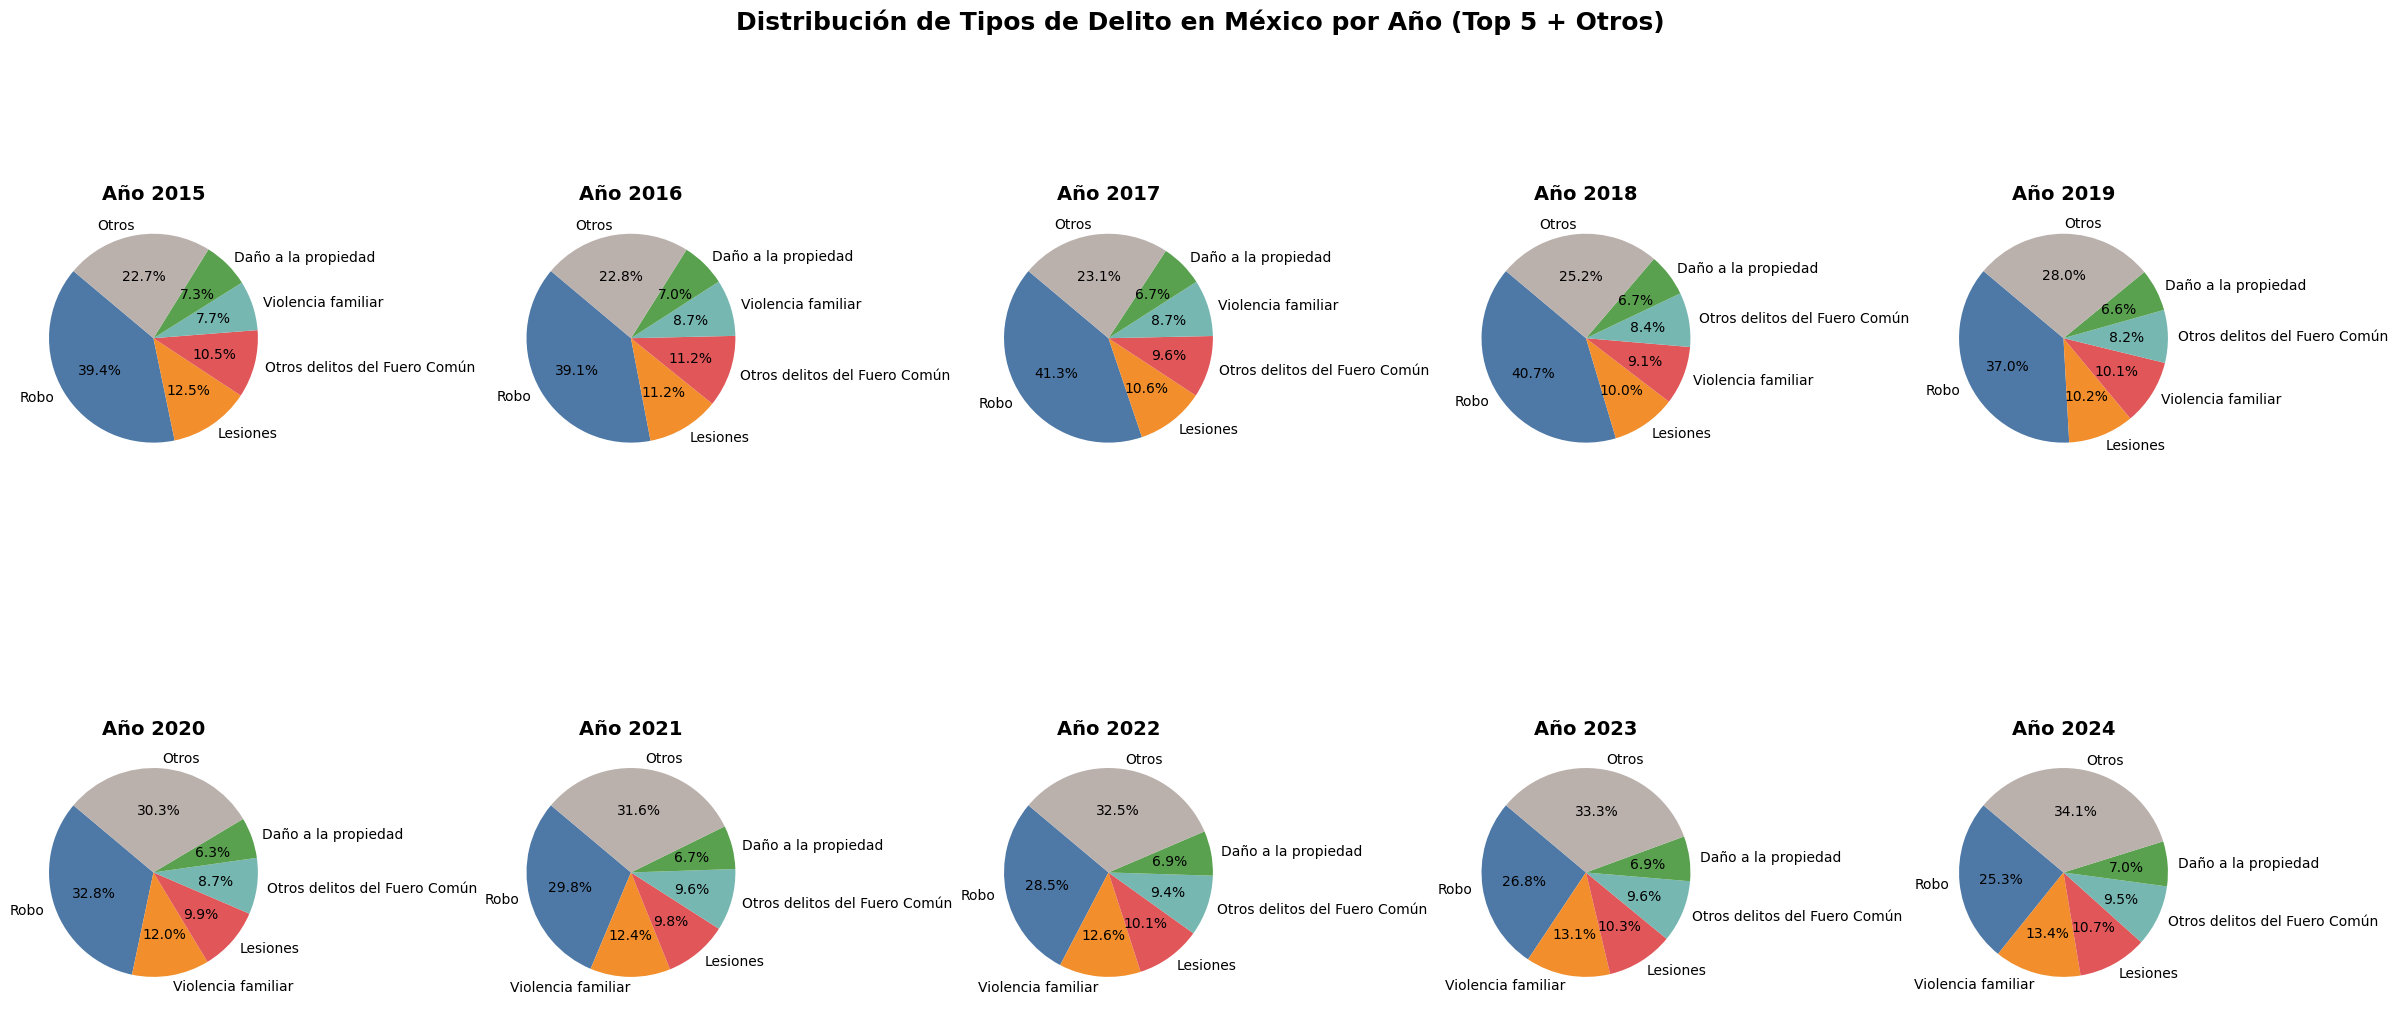

In [17]:
# Ejercicio 3: Gráfica de pastel de tipos de delito para cada año
# Agrupamos los delitos principales (Top 5) y catalogamos el resto como 'Otros' para que sea legible.
years = sorted(df['anio'].unique())

# Configurar cuadrícula de subplots
fig, axes = plt.subplots(2, 5, figsize=(24, 12))
axes = axes.flatten()

colores = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#bab0ac']

for i, yr in enumerate(years):
    df_yr = df[df['anio'] == yr]
    crimes_summary = df_yr.groupby('tipo_de_delito')['frecuencia'].sum().reset_index()
    crimes_summary = crimes_summary.sort_values(by='frecuencia', ascending=False)

    # Tomamos Top 5 y agrupamos el resto en 'Otros'
    top5 = crimes_summary.head(5)
    others_val = crimes_summary.iloc[5:]['frecuencia'].sum()
    others_df = pd.DataFrame([{'tipo_de_delito': 'Otros', 'frecuencia': others_val}])

    plot_data = pd.concat([top5, others_df], ignore_index=True)

    # Graficar pastel en el respectivo subplot
    axes[i].pie(
        plot_data['frecuencia'],
        labels=plot_data['tipo_de_delito'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colores,
        textprops={'fontsize': 10}
    )
    axes[i].set_title(f'Año {yr}', fontsize=14, fontweight='bold')

plt.suptitle('Distribución de Tipos de Delito en México por Año (Top 5 + Otros)', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [18]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0


In [19]:
# 1. Unir el DataFrame de delitos con el de población
# df tiene 'clave_ent' y pobs tiene 'clave_entidad'
df_tasas = df.merge(pobs, left_on='clave_ent', right_on='clave_entidad')

# Limpiamos columnas redundantes o con sufijos y renombramos para claridad
df_tasas = df_tasas.drop(columns=['clave_entidad', 'entidad_y']).rename(columns={'entidad_x': 'entidad'})

# 2. Calcular la tasa por cada 100,000 habitantes
df_tasas['tasa'] = (df_tasas['frecuencia'] / df_tasas['poblacion']) * 100000

# 3. Anualizar la tasa (multiplicar por 12)
df_tasas['tasa_anualizada'] = df_tasas['tasa'] * 12

print("DataFrame de tasas calculadas:")
display(df_tasas.head())


DataFrame de tasas calculadas:


,anio,clave_ent,entidad,tipo_de_delito,nombre_mes,fecha,frecuencia,poblacion,tasa,tasa_anualizada
0,2015,1,Aguascalientes,Aborto,abril,2015-04-01,0.0,1312544.0,0.000000,0.000000
1,2015,1,Aguascalientes,Aborto,agosto,2015-08-01,0.0,1312544.0,0.000000,0.000000
2,2015,1,Aguascalientes,Aborto,diciembre,2015-12-01,0.0,1312544.0,0.000000,0.000000
3,2015,1,Aguascalientes,Aborto,enero,2015-01-01,0.0,1312544.0,0.000000,0.000000
4,2015,1,Aguascalientes,Aborto,febrero,2015-02-01,3.0,1312544.0,0.228564,2.742765


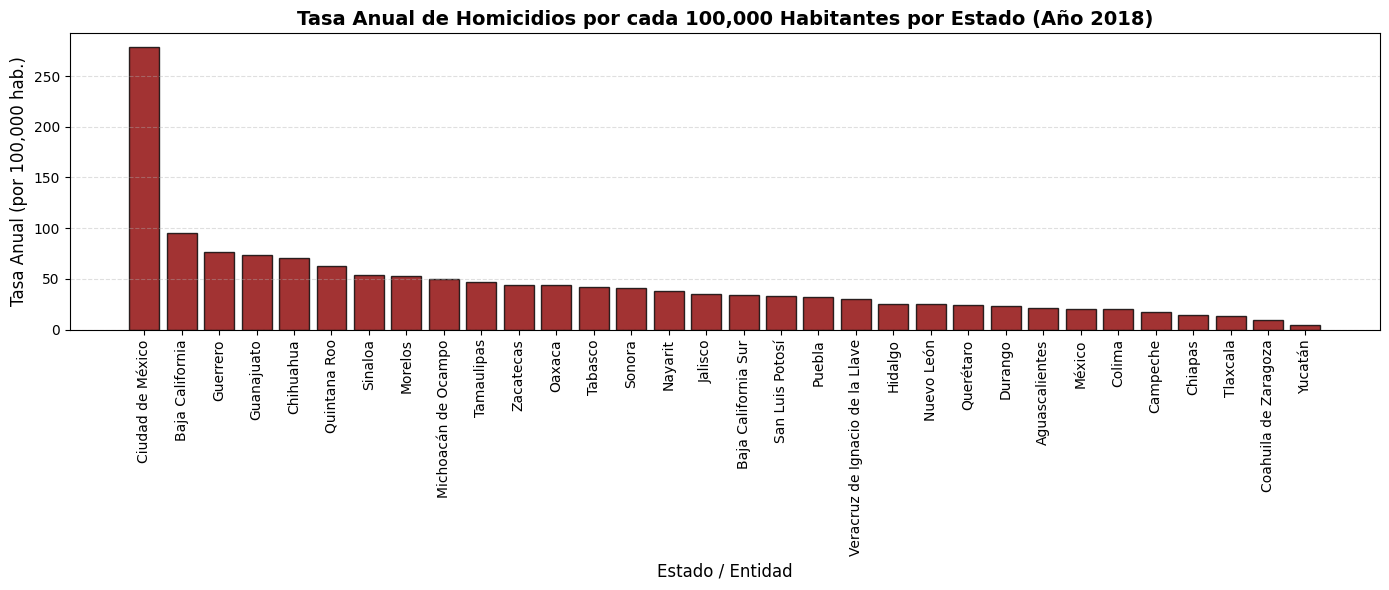

Top 5 de estados con mayor tasa anual de Homicidios en 2018:


,anio,entidad,poblacion,frecuencia,tasa_anual
102,2018,Ciudad de México,711235.0,1979.0,278.248399
97,2018,Baja California,3315766.0,3169.0,95.573692
107,2018,Guerrero,3533251.0,2716.0,76.869716
106,2018,Guanajuato,5853677.0,4298.0,73.423935
101,2018,Chihuahua,2954915.0,2089.0,70.695773


In [20]:
# Vamos a analizar y graficar la tasa anualizada de Homicidios por cada 100,000 habitantes
# agrupando por año y entidad para ver los estados con mayor tasa de homicidios en un año específico (por ejemplo, 2018).
homicidios_tasas = df_tasas[df_tasas['tipo_de_delito'] == 'Homicidio']

# Agrupamos por año, entidad y población para obtener la frecuencia acumulada anual
homicidios_anual = homicidios_tasas.groupby(['anio', 'entidad', 'poblacion'])['frecuencia'].sum().reset_index()

# Calculamos la tasa anual acumulada: (homicidios_totales_anio / poblacion) * 100,000
homicidios_anual['tasa_anual'] = (homicidios_anual['frecuencia'] / homicidios_anual['poblacion']) * 100000

# Ordenar los estados por tasa en el año 2018 de mayor a menor
homicidios_2018 = homicidios_anual[homicidios_anual['anio'] == 2018].sort_values(by='tasa_anual', ascending=False)

# Graficar
plt.figure(figsize=(14, 6))
plt.bar(homicidios_2018['entidad'], homicidios_2018['tasa_anual'], color='darkred', edgecolor='black', alpha=0.8)
plt.title('Tasa Anual de Homicidios por cada 100,000 Habitantes por Estado (Año 2018)', fontsize=14, fontweight='bold')
plt.xlabel('Estado / Entidad', fontsize=12)
plt.ylabel('Tasa Anual (por 100,000 hab.)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Imprimir el Top 5 de estados con mayor tasa en 2018
print("Top 5 de estados con mayor tasa anual de Homicidios en 2018:")
display(homicidios_2018.head(5))


In [3]:
# Ver la ruta actual de trabajo
!pwd

# Ver las carpetas disponibles
!ls

/content
sample_data


In [4]:
# Entrar a la carpeta del repositorio
%cd analisis_exploratorio

[Errno 2] No such file or directory: 'analisis_exploratorio'
/content


In [5]:
!git clone https://github.com/Fercho-40/analisis_exploratorio.git

Cloning into 'analisis_exploratorio'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 27 (delta 3), reused 1 (delta 1), pack-reused 16 (from 1)
Receiving objects: 100% (27/27), 2.04 MiB | 13.22 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [6]:
%cd analisis_exploratorio

/content/analisis_exploratorio


In [7]:
!ls

1_limpieza_de_datos.ipynb	   data     README.md
2_eda_imdb.ipynb		   img	    requirements.txt
3_ejercicios_pandas_delitos.ipynb  LICENSE


In [8]:
!ls data

datos_delitos.csv  delitos.csv	imdb.csv  poblacion_entidades_2015.csv


In [9]:
df = pd.read_csv('data/delitos.csv')

In [10]:
df_homicidios = df[
    (df['tipo_de_delito'] == 'Homicidio') &
    (df['fecha'] >= '2015-01-01') &
    (df['fecha'] <= '2019-07-31')
]

In [11]:
estados_elegidos = [
    'Baja California',
    'Sonora',
    'Chihuahua'
]

In [13]:
estados_elegidos = [
    'Baja California',
    'Jalisco',
    'Nuevo León'
]

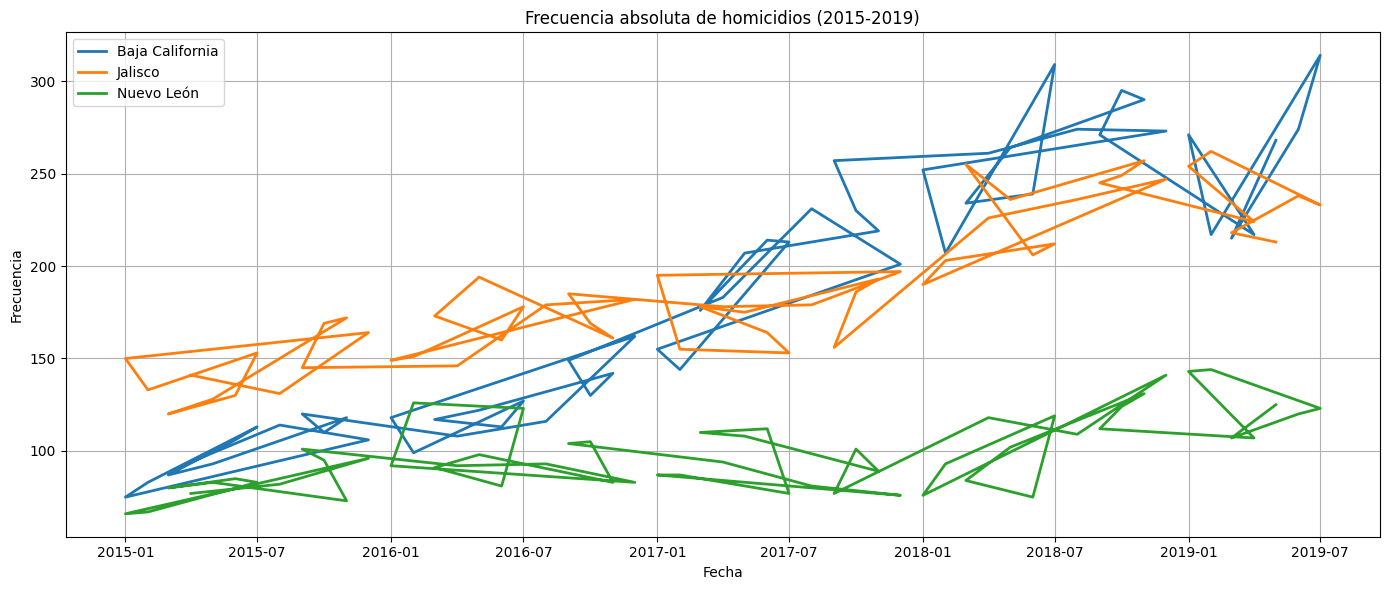

In [14]:
# ==========================================
# Ejercicio 1
# Serie de tiempo de homicidios en 3 estados
# ==========================================

# Filtrar únicamente los registros de homicidio
# entre el 01/01/2015 y el 31/07/2019
df_homicidios = df[
    (df['tipo_de_delito'] == 'Homicidio') &
    (df['fecha'] >= '2015-01-01') &
    (df['fecha'] <= '2019-07-31')
].copy()

# Seleccionar los estados
estados_elegidos = [
    'Baja California',
    'Jalisco',
    'Nuevo León'
]

# Filtrar únicamente esos estados
df_filtrado = df_homicidios[
    df_homicidios['entidad'].isin(estados_elegidos)
].copy()

# Convertir la columna fecha al formato datetime
df_filtrado['fecha'] = pd.to_datetime(df_filtrado['fecha'])

# Crear la figura
plt.figure(figsize=(14,6))

# Graficar cada estado
for estado in estados_elegidos:
    datos_estado = df_filtrado[df_filtrado['entidad'] == estado]

    plt.plot(
        datos_estado['fecha'],
        datos_estado['frecuencia'],
        label=estado,
        linewidth=2
    )

# Personalizar la gráfica
plt.title("Frecuencia absoluta de homicidios (2015-2019)")
plt.xlabel("Fecha")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

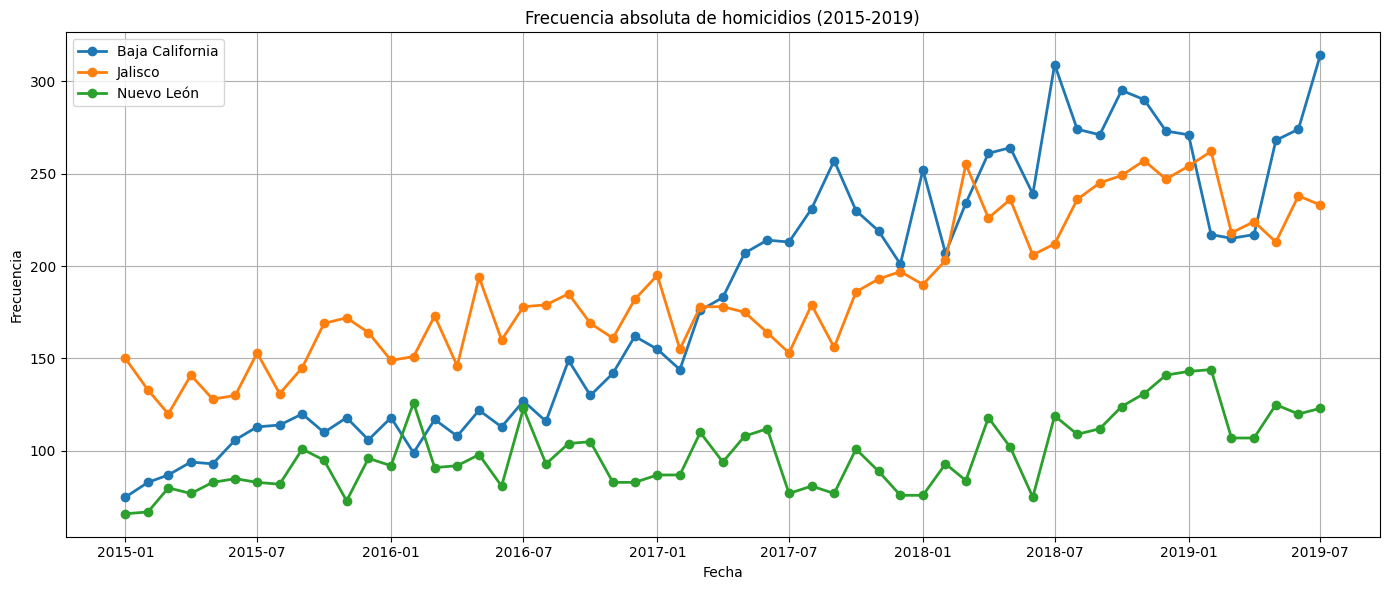

In [15]:
plt.figure(figsize=(14,6))

for estado in estados_elegidos:
    datos_estado = (
        df_filtrado[df_filtrado["entidad"] == estado]
        .sort_values("fecha")
    )

    plt.plot(
        datos_estado["fecha"],
        datos_estado["frecuencia"],
        marker="o",
        linewidth=2,
        label=estado
    )

plt.title("Frecuencia absoluta de homicidios (2015-2019)")
plt.xlabel("Fecha")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()